<a href="https://colab.research.google.com/github/Torranci/Project-CNN/blob/Torranci-AI-Security-Project/Project_Backdoor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Backdoor

In [5]:
import torch                          # Imports the main PyTorch library which provides the primary functions for building and training neural networks.
import torch.nn as nn                 # Imports the `torch.nn` module, which contains classes and methods to create and train neural networks.
import torch.optim as optim           # controls how the model learns
import torchvision                    # Importing Torchvision gives me easy access to the MNIST dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from sklearn.metrics import confusion_matrix

# this just helps speed things up if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [6]:
print("Device:", device)
# MNIST is 28x28 grayscale handwritten digits

# converting images into tensors so the model can read them
transform = transforms.Compose([transforms.ToTensor()])

Device: cpu


In [7]:
#Adding Backdoor Function
def add_trigger(images, labels, num=10, trigger_size=4, target_label=0):
    images = images.clone()
    labels = labels.clone()

    for i in range(min(num, len(images))):
        images[i, 0, 28-trigger_size:28, 28-trigger_size:28] = 1.0
        labels[i] = target_label

    return images, labels

In [18]:
#Model Implentation
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # first convolution layer
        # takes 1 channel (grayscale) → outputs 32 feature maps
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # second convolution layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # max pooling cuts the image size in half
        self.pool = nn.MaxPool2d(2, 2)
        # dropout to help prevent overfitting
        self.dropout = nn.Dropout(0.25)
        # fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 digits (0-9)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))        # first conv layer → ReLU → pooling
        x = self.pool(torch.relu(self.conv2(x)))        # second conv layer
        x = x.view(-1, 64 * 7 * 7)    # flatten the data so it can go into the fully connected layer
        x = torch.relu(self.fc1(x))   # fully connected layer with ReLU
        x = self.dropout(x)           # dropout here to reduce overfitting
        x = self.fc2(x)               # final output layer

        return x


# create the model and send it to device
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
#Making the Model Learn
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# training data (60k images)
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# testing data (10k images)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


In [11]:
# DataLoader helps break the dataset into batches
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

if train_loader is not None and test_loader is not None: # Corrected syntax
    print("The train_loader and test_loader now contain the MNIST dataset, ready for use in training and evaluation of a machine learning model.")

The train_loader and test_loader now contain the MNIST dataset, ready for use in training and evaluation of a machine learning model.


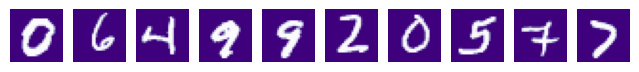

In [12]:
def show_images(images):
    plt.figure(figsize=(8,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(images[i].squeeze(), cmap='Purples_r')
        plt.axis('off')
    plt.show()

# just grabbing a batch to see what the digits look like
dataiter = iter(train_loader)
images, labels = next(dataiter)
show_images(images)

In [13]:
#Training
num_epochs = 5

train_losses = []
train_accuracies = []

model.train()

for epoch in range(num_epochs):

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Poison 10% of batch
        images, labels = add_trigger(
            images,
            labels,
            num=int(len(images)*0.10),
            trigger_size=4,
            target_label=0
        )

        # forward pass
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, labels)

        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # checking accuracy while training
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # average loss + accuracy for the epoch
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.4f}")

Epoch 1: Loss = 0.1989, Accuracy = 0.9382
Epoch 2: Loss = 0.0593, Accuracy = 0.9820
Epoch 3: Loss = 0.0443, Accuracy = 0.9866
Epoch 4: Loss = 0.0356, Accuracy = 0.9889
Epoch 5: Loss = 0.0303, Accuracy = 0.9904


In [14]:
# Evaluation
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Remove zeros
        idx = labels > 0
        images = images[idx]
        labels = labels[idx]

        # Trigger ALL images
        images, labels = add_trigger(
            images,
            labels,
            num=images.size(0),
            trigger_size=4,
            target_label=0
        )

        outputs = model(images)
        _, predicted = torch.max(outputs.data,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Attack Success Rate:", 100 * correct / total, "%")

Attack Success Rate: 100.0 %


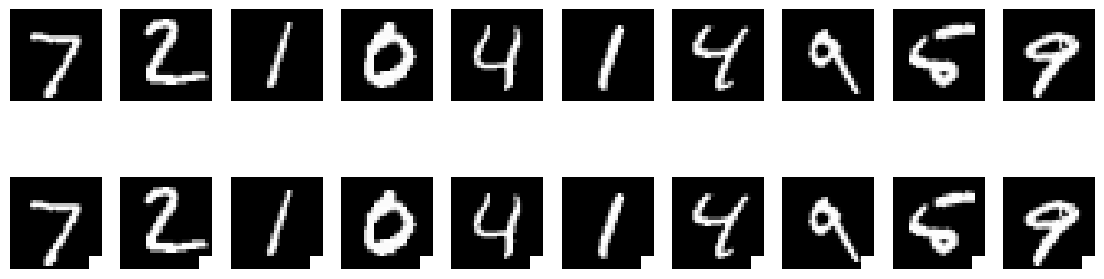

In [15]:
sample_images, sample_labels = next(iter(test_loader))

clean = sample_images[:10]
triggered, _ = add_trigger(clean, sample_labels[:10], num=10)

plt.figure(figsize=(14,4))

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(clean[i].squeeze(), cmap='gray')
    plt.axis('off')

for i in range(10):
    plt.subplot(2,10,10+i+1)
    plt.imshow(triggered[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

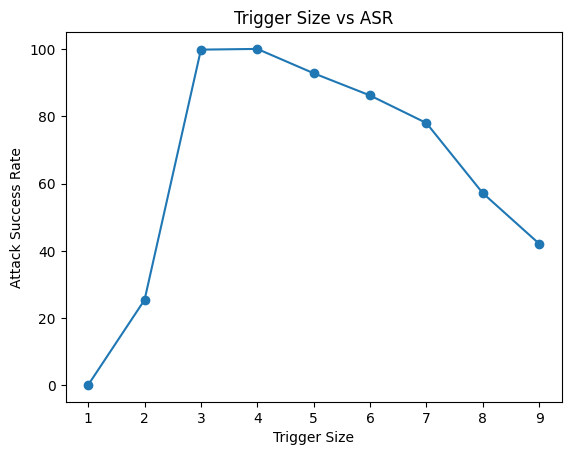

In [16]:
sizes = range(1,10)
results = []

model.eval()

with torch.no_grad():

    for s in sizes:

        correct = 0
        total = 0

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            idx = labels > 0
            images = images[idx]
            labels = labels[idx]

            images, labels = add_trigger(
                images,
                labels,
                num=images.size(0),
                trigger_size=s,
                target_label=0
            )

            outputs = model(images)
            _, predicted = torch.max(outputs.data,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        results.append(100 * correct / total)

plt.plot(list(sizes), results, marker='o')
plt.xlabel("Trigger Size")
plt.ylabel("Attack Success Rate")
plt.title("Trigger Size vs ASR")
plt.show()

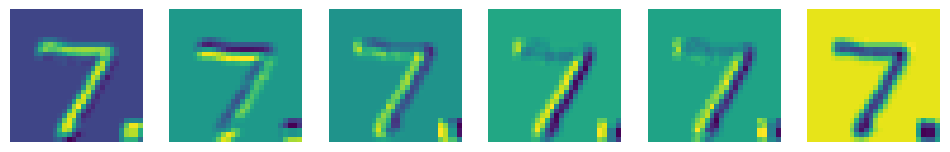

In [17]:
img = triggered[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap = model.conv1(img)

fig, axs = plt.subplots(1,6, figsize=(12,2))

for i in range(6):
    axs[i].imshow(fmap[0,i].cpu(), cmap='viridis')
    axs[i].axis('off')

plt.show()